In [1]:
!pip install hls4ml qkeras tensorflow
import hls4ml
import qkeras
# Potem zrestartuj środowisko wykonawcze (Runtime -> Restart session)

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.8/152.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.7/242.7 kB 14.5 MB/s eta 0:00:00
  Created wheel for pyparser: filename=pyparser-1.0-py3-none-any.whl size=4913 sha256=6e84692c1ede543a43e07128f1ce60d4bb39c6f215198a6fd541eaca4d6624d7
  Stored in directory: /root/.cache/pip/wheels/8a/3c/76/230d8b2fb827b8800888f2b2b30b740d8deee200e3f7e6ae5f
  Created wheel for parse: filename=parse-1.6.5-py3-none-any.whl size=18155 sha256=893b90ad8ef6fa714661e59e3991585edb63a2828f3245d38c65582697a4e97b
  Stored in directory: /root/.cache/pip/wheels/24/7c/c1/22fcbf2f2cfbd337610466d1ba28eab2856bb02ea706378253
Successfully built pyparser parse


In [1]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Activation
from qkeras import QDense, QConv2D, QActivation, quantized_bits

# Pobranie danych
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
y_train, y_test = tf.one_hot(y_train, 10), tf.one_hot(y_test, 10)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [2]:
model = Sequential([
    Conv2D(8, kernel_size=(3,3), input_shape=(28,28,1), name='conv_0'),
    Activation('relu', name='act_0'),
    MaxPooling2D(pool_size=(2,2), name='pool_0'),
    Flatten(name='flatten'),
    Dense(32, name='dense_0'),
    Activation('relu', name='act_1'),
    Dense(10, name='output_dense'),
    Activation('softmax', name='softmax')
], name='baseline_model')

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(x_train[..., np.newaxis], y_train, epochs=2, batch_size=128)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/2
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.8797 - loss: 0.4221
Epoch 2/2
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.9615 - loss: 0.1351


In [5]:
import hls4ml
import numpy as np
from sklearn.metrics import accuracy_score

# Definiujemy, które warstwy będziemy "psuć" (kwantyzować)
layers_to_test = ['conv_0', 'dense_0', 'output_dense']
results = {}

for target_layer in layers_to_test:
    # 1. Konfiguracja domyślna (wysoka precyzja)
    config = hls4ml.utils.config_from_keras_model(model, granularity='name')
    config['Model']['Precision'] = 'ap_fixed<16,6>'

    # 2. Kwantyzujemy tylko JEDNĄ wybraną warstwę na 4-bity
    config['LayerName'][target_layer]['Precision']['weight'] = 'ap_fixed<4,1>'
    config['LayerName'][target_layer]['Precision']['bias'] = 'ap_fixed<4,1>'

    # 3. Symulacja sprzętowa (bez syntezy)
    # Dodajemy parametr part='xc7z020clg484-1', żeby uniknąć błędów z brakiem części
    hls_model = hls4ml.converters.convert_from_keras_model(model, hls_config=config, output_dir='hls_prj', part='xc7z020clg400-1')
    hls_model.compile()

    # 4. Test dokładności
    # Upewnij się, że x_test ma odpowiedni kształt
    y_hls = hls_model.predict(x_test[..., np.newaxis])
    acc = accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_hls, axis=1))
    results[target_layer] = acc
    print(f"Po kwantyzacji {target_layer} na 4-bity, Accuracy wynosi: {acc:.4f}")

Po kwantyzacji conv_0 na 4-bity, Accuracy wynosi: 0.0980
Po kwantyzacji dense_0 na 4-bity, Accuracy wynosi: 0.0980
Po kwantyzacji output_dense na 4-bity, Accuracy wynosi: 0.8027


Zawartość słownika results: {'conv_0': 0.098, 'dense_0': 0.098, 'output_dense': 0.8027}


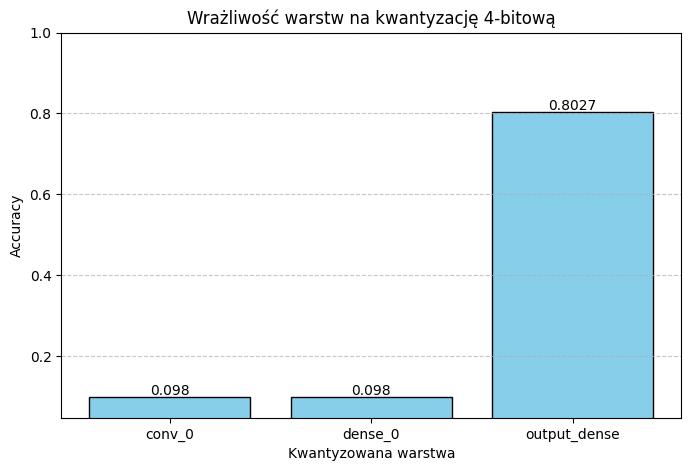

In [7]:
import matplotlib.pyplot as plt

# 1. Sprawdźmy, czy w ogóle mamy dane
print("Zawartość słownika results:", results)

if not results:
    print("Błąd: Słownik 'results' jest pusty. Uruchom jeszcze raz pętlę z poprzedniej komórki!")
else:
    # 2. Przygotowanie danych
    names = list(results.keys())
    values = list(results.values())

    # 3. Rysowanie
    plt.figure(figsize=(8, 5))
    bars = plt.bar(names, values, color='skyblue', edgecolor='black')

    # 4. Automatyczne ustawienie zakresu Y, żeby słupki były widoczne
    # Ustawiamy zakres od 0 do 1.0 (zakładając accuracy 0-100%)
    plt.ylim(min(values) - 0.05, 1.0)

    plt.title("Wrażliwość warstw na kwantyzację 4-bitową")
    plt.ylabel("Accuracy")
    plt.xlabel("Kwantyzowana warstwa")
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Dodanie wartości na słupkach
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 4), ha='center', va='bottom')

    plt.show()